<a href="https://colab.research.google.com/github/RafaelCardoso140701/Projetos-Data-Science/blob/main/Analise_exploratoria_genero_musicais_pelo_mundo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install kneed

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import os # Import the os module

pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 300)

# Download latest version
path = kagglehub.dataset_download("atharvasoundankar/global-music-streaming-trends-and-listener-insights")
#path = kagglehub.dataset_download("wardabilal/spotify-global-music-dataset-20092025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-music-streaming-trends-and-listener-insights' dataset.
Path to dataset files: /kaggle/input/global-music-streaming-trends-and-listener-insights


In [ ]:
# Caminho para o arquivo CSV
file_path = os.path.join(path, "Global_Music_Streaming_Listener_Preferences.csv")
#file_path = /kaggle/input/spotify-global-music-dataset-20092025

# Carregar o dataset usando pandas
df = pd.read_csv(file_path)

# Exibir as primeiras 5 linhas
df = pd.DataFrame(df)
print(df.head())

  User_ID  Age    Country Streaming Platform Top Genre  Minutes Streamed Per Day  Number of Songs Liked Most Played Artist Subscription Type Listening Time (Morning/Afternoon/Night)  Discover Weekly Engagement (%)  Repeat Song Rate (%)
0   U1000   34      Japan              Tidal    Reggae                       295                    138              Adele              Free                                Afternoon                           47.42                 16.74
1   U1001   24    Germany             Deezer   Country                        86                    388         Ed Sheeran           Premium                                    Night                           12.06                 69.25
2   U1002   49    Germany             Deezer       Pop                       363                    368        Post Malone           Premium                                Afternoon                           47.19                 67.38
3   U1003   55  Australia            YouTube    Reggae  

In [ ]:
# Exibir informações detalhadas sobre o DataFrame
print("Informações gerais sobre o dataset:")
df.info()

Informações gerais sobre o dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User_ID                                   5000 non-null   object 
 1   Age                                       5000 non-null   int64  
 2   Country                                   5000 non-null   object 
 3   Streaming Platform                        5000 non-null   object 
 4   Top Genre                                 5000 non-null   object 
 5   Minutes Streamed Per Day                  5000 non-null   int64  
 6   Number of Songs Liked                     5000 non-null   int64  
 7   Most Played Artist                        5000 non-null   object 
 8   Subscription Type                         5000 non-null   object 
 9   Listening Time (Morning/Afternoon/Night)  5000 non-null   object 
 10  

In [ ]:
# Primeiro, separe pelos tipos básicos
# Colunas numéricas que devem permanecer numéricas
num_cols_initial = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Colunas categóricas iniciais
cat_cols_initial = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

# Colunas numéricas que devem ser tratadas como categóricas
categoricas_adicionais = ['Age']

# Remover 'Age' da lista de colunas numéricas
num_cols_final = [col for col in num_cols_initial if col not in categoricas_adicionais]

# Adicionar 'Age' à lista de colunas categóricas
cat_cols_final = cat_cols_initial + categoricas_adicionais

# Criar os DataFrames finais
numericas = df[num_cols_final].copy()
categoricas = df[cat_cols_final].copy()


print("\nColunas Categóricas (tratadas):")
print(categoricas.columns.tolist())
print(numericas.columns.tolist())


print(f"\nTotal de colunas numéricas: {numericas.shape[1]}")
print(f"Total de colunas categóricas: {categoricas.shape[1]}")


Colunas Categóricas (tratadas):
['User_ID', 'Country', 'Streaming Platform', 'Top Genre', 'Most Played Artist', 'Subscription Type', 'Listening Time (Morning/Afternoon/Night)', 'Age']
['Minutes Streamed Per Day', 'Number of Songs Liked', 'Discover Weekly Engagement (%)', 'Repeat Song Rate (%)']

Total de colunas numéricas: 4
Total de colunas categóricas: 8


In [ ]:
# Encontrar e exibir os valores mínimo e máximo
a = categoricas['Age'].min()
b = categoricas['Age'].max()
print(a,b)

13 60


In [ ]:
# Encontrar e exibir média aredondada
categoricas['Age'].mean().round(0)

np.float64(37.0)

In [ ]:
df_final_features_unified = df.copy()

columns_to_label_encode = ['Country', 'Streaming Platform', 'Top Genre', 'Subscription Type', 'Most Played Artist', 'Listening Time (Morning/Afternoon/Night)']

# Perform label encoding and store mappings (if needed later)
label_mappings_unified = {}
for col in columns_to_label_encode:
    df_final_features_unified[f'{col}_ID'], uniques = pd.factorize(df_final_features_unified[col])
    label_mappings_unified[col] = {value: i for i, value in enumerate(uniques)}

print("DataFrame com colunas originais e de ID (primeiras 5 linhas):")
print(df_final_features_unified.head())

print(f"\nColunas no DataFrame final: {df_final_features_unified.columns.tolist()}")

print("\nAlguns mapeamentos de IDs:")
for col, mapping in label_mappings_unified.items():
    print(f"\n{col} Mapeamento:")
    print(list(mapping.items())[:5]) # Print first 5 mappings for brevity


DataFrame com colunas originais e de ID (primeiras 5 linhas):
  User_ID  Age    Country Streaming Platform Top Genre  Minutes Streamed Per Day  Number of Songs Liked Most Played Artist Subscription Type Listening Time (Morning/Afternoon/Night)  Discover Weekly Engagement (%)  Repeat Song Rate (%)  Country_ID  Streaming Platform_ID  Top Genre_ID  Subscription Type_ID  Most Played Artist_ID  Listening Time (Morning/Afternoon/Night)_ID
0   U1000   34      Japan              Tidal    Reggae                       295                    138              Adele              Free                                Afternoon                           47.42                 16.74           0                      0             0                     0                      0                                            0
1   U1001   24    Germany             Deezer   Country                        86                    388         Ed Sheeran           Premium                                    Night       

In [ ]:
features = [
    #"Age",
    "Country_ID",
    "Minutes Streamed Per Day",
    #"Number of Songs Liked",
    #"Discover Weekly Engagement (%)",
    #"Repeat Song Rate (%)"
]

X = df_final_features_unified[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

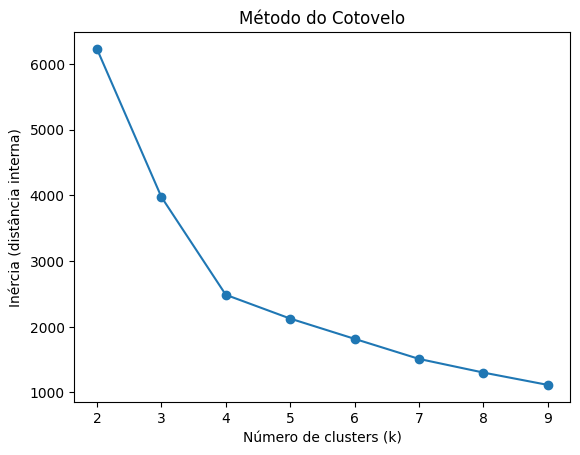

In [ ]:
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (distância interna)")
plt.title("Método do Cotovelo")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_final_features_unified["Cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = df_final_features_unified.groupby("Cluster")[features].mean().round(2)
print(cluster_summary)

print(df_final_features_unified["Cluster"].value_counts())

         Country_ID  Minutes Streamed Per Day
Cluster                                      
0              2.04                    452.19
1              7.03                    454.31
2              6.93                    155.82
3              2.03                    154.67
Cluster
0    1348
2    1244
1    1236
3    1172
Name: count, dtype: int64


In [ ]:
# Create a reverse mapping from Country_ID to Country name
country_id_to_name = {v: k for k, v in label_mappings_unified['Country'].items()}

# Group by Cluster and Country_ID and sum Minutes Streamed Per Day
cluster_country_minutes = df_final_features_unified.groupby(['Cluster', 'Country_ID'])['Minutes Streamed Per Day'].sum().reset_index()

# Get the top 4 countries for each cluster
top_countries_per_cluster = cluster_country_minutes.groupby('Cluster').apply(lambda x: x.nlargest(4, 'Minutes Streamed Per Day')).reset_index(drop=True)

# Map Country_ID back to Country Name for better readability
top_countries_per_cluster['Country'] = top_countries_per_cluster['Country_ID'].map(country_id_to_name)

print("Top 4 países com mais minutos ouvidos por Cluster:")
display(top_countries_per_cluster.sort_values(by=['Cluster', 'Minutes Streamed Per Day'], ascending=[True, False]))


Top 4 países com mais minutos ouvidos por Cluster:


/tmp/ipython-input-838999671.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_countries_per_cluster = cluster_country_minutes.groupby('Cluster').apply(lambda x: x.nlargest(4, 'Minutes Streamed Per Day')).reset_index(drop=True)


,Cluster,Country_ID,Minutes Streamed Per Day,Country
0,0,2,126710,Australia
1,0,3,126658,South Korea
2,0,4,122199,UK
3,0,1,119996,Germany
4,1,9,122044,France
5,1,6,113458,Canada
6,1,7,112083,India
7,1,5,109015,Brazil
8,2,6,42542,Canada
9,2,5,40191,Brazil


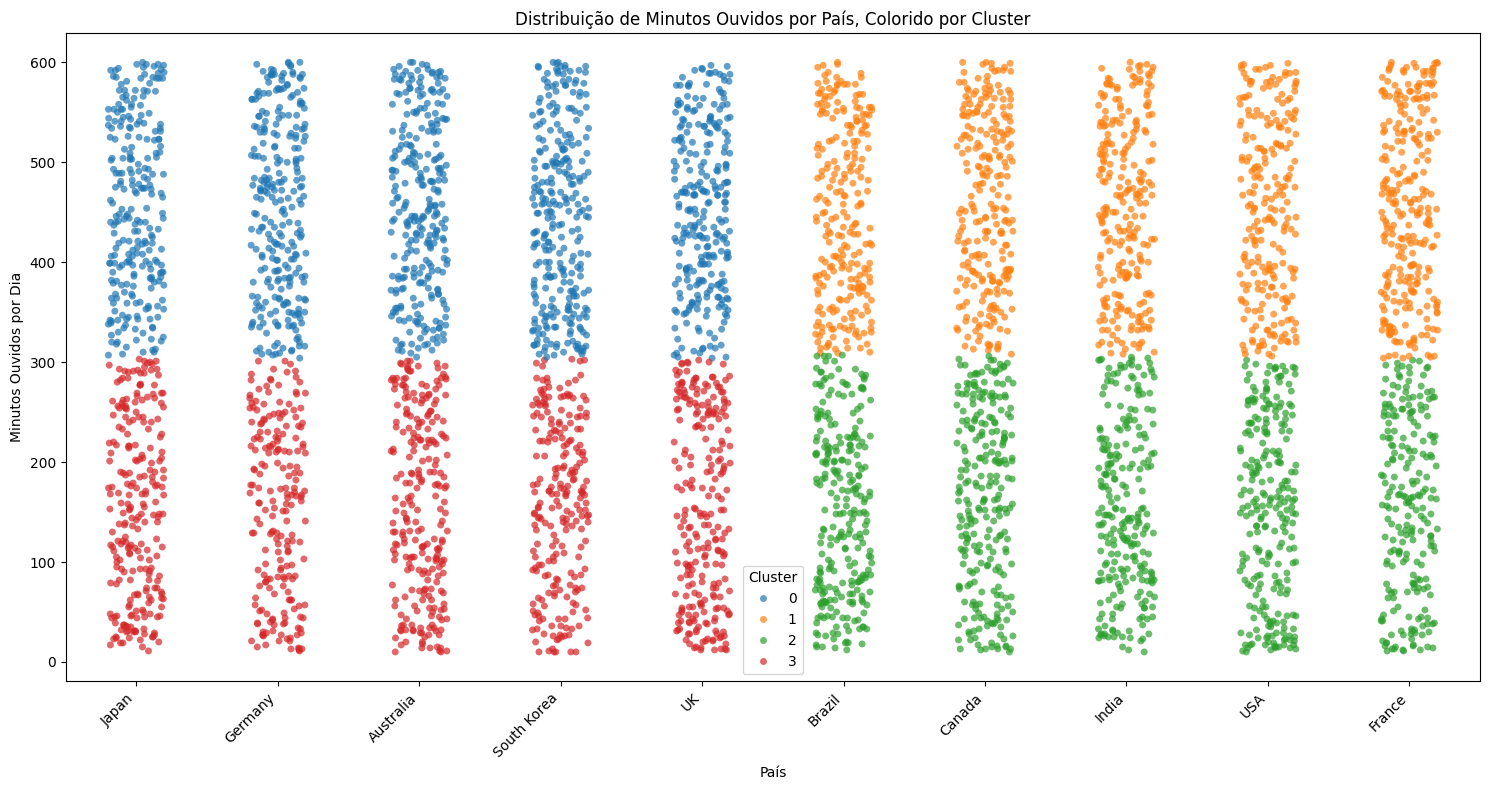

In [ ]:
# Map Country_ID back to Country Name for better readability
df_final_features_unified['Country_Name'] = df_final_features_unified['Country_ID'].map(country_id_to_name)

# Create a stripplot to show individual points, colored by Cluster
plt.figure(figsize=(15, 8))
sns.stripplot(
    data=df_final_features_unified,
    x='Country_Name',
    y='Minutes Streamed Per Day',
    hue='Cluster',
    palette='tab10', # Use a distinct color palette for clusters
    jitter=0.2, # Add jitter to prevent overplotting
    alpha=0.7 # Adjust transparency for better visibility
)

plt.title('Distribuição de Minutos Ouvidos por País, Colorido por Cluster')
plt.xlabel('País')
plt.ylabel('Minutos Ouvidos por Dia')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


# Task
Crie um mapeamento de `Top Genre_ID` para os nomes dos gêneros musicais, adicione esta informação ao `df_final_features_unified` como `Top_Genre_Name` e, em seguida, visualize a distribuição dos 'Minutos Ouvidos por Dia' por gênero em cada país usando gráficos de dispersão. Identifique o segundo gênero musical mais ouvido em cada país com base no total de minutos ouvidos e apresente essas recomendações.

## Criar Mapeamento de Nome do Gênero

### Subtask:
Criar um mapeamento reverso de `Top Genre_ID` para os nomes dos gêneros musicais e adicionar uma nova coluna `Top_Genre_Name` ao `df_final_features_unified` para facilitar a visualização.


**Reasoning**:
To create a reverse mapping for 'Top Genre_ID' to the original genre names and add it as a new column to the DataFrame, I will first create a reverse mapping dictionary and then use it to map the existing 'Top Genre_ID' column.



In [ ]:
genre_id_to_name = {v: k for k, v in label_mappings_unified['Top Genre'].items()}
df_final_features_unified['Top_Genre_Name'] = df_final_features_unified['Top Genre_ID'].map(genre_id_to_name)

print("DataFrame com a nova coluna 'Top_Genre_Name' (primeiras 5 linhas):")
print(df_final_features_unified.head())

DataFrame com a nova coluna 'Top_Genre_Name' (primeiras 5 linhas):
  User_ID  Age    Country Streaming Platform Top Genre  Minutes Streamed Per Day  Number of Songs Liked Most Played Artist Subscription Type Listening Time (Morning/Afternoon/Night)  ...  Streaming Platform_ID  Top Genre_ID  Subscription Type_ID  Most Played Artist_ID  Listening Time (Morning/Afternoon/Night)_ID  Cluster      PCA1      PCA2  Country_Name  Top_Genre_Name
0   U1000   34      Japan              Tidal    Reggae                       295                    138              Adele              Free                                Afternoon  ...                      0             0                     0                      0                                            0        3  1.056426 -1.173478         Japan          Reggae
1   U1001   24    Germany             Deezer   Country                        86                    388         Ed Sheeran           Premium                                    Night  ... 

## Visualizar Minutos Ouvidos por Gênero em Cada País

### Subtask:
Gerar uma série de gráficos de dispersão (stripplots), onde cada gráfico representa um país diferente, mostrando a distribuição dos 'Minutos Ouvidos por Dia' para cada gênero musical dentro daquele país. Isso ajudará a entender visualmente a popularidade dos gêneros.


**Reasoning**:
To visualize the distribution of 'Minutes Streamed Per Day' by 'Top_Genre_Name' for each country, I need to iterate through each unique country, filter the DataFrame for that country, and then generate a stripplot using `seaborn` and `matplotlib`.



/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


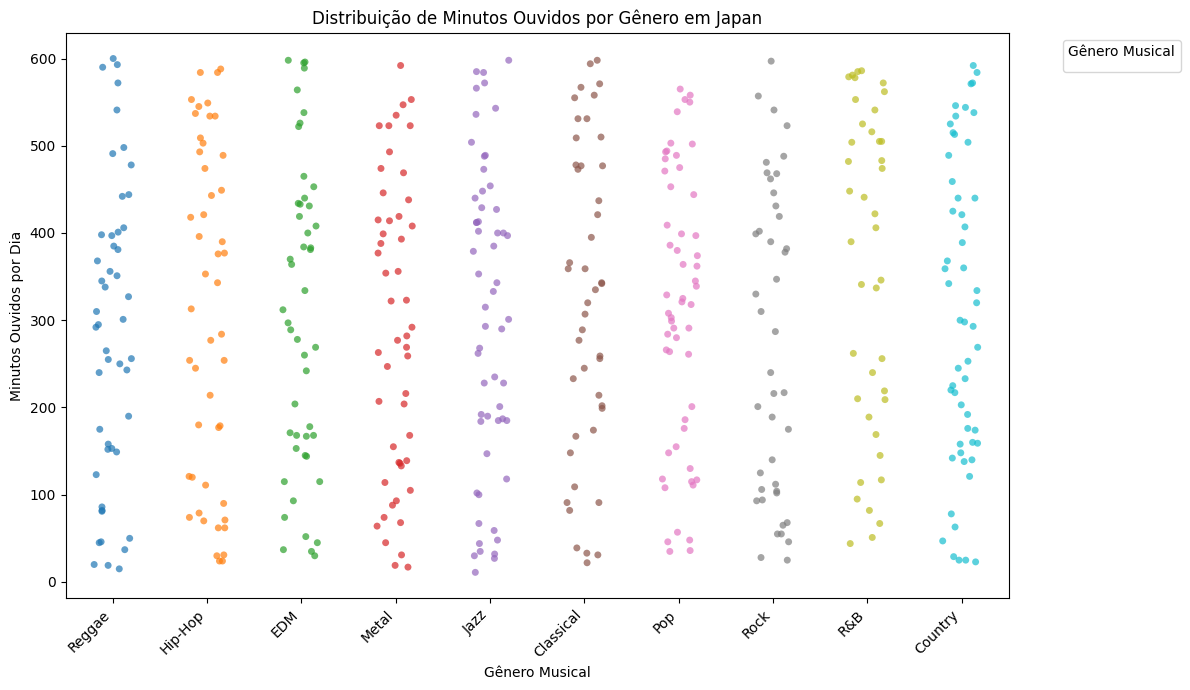

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


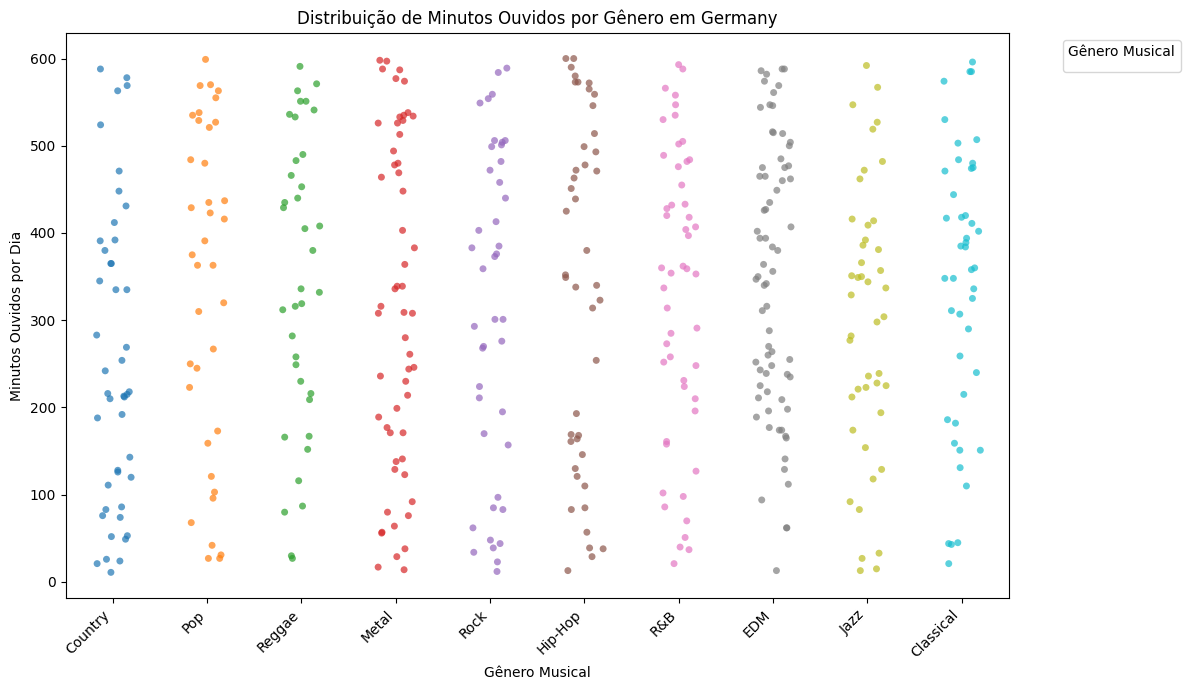

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


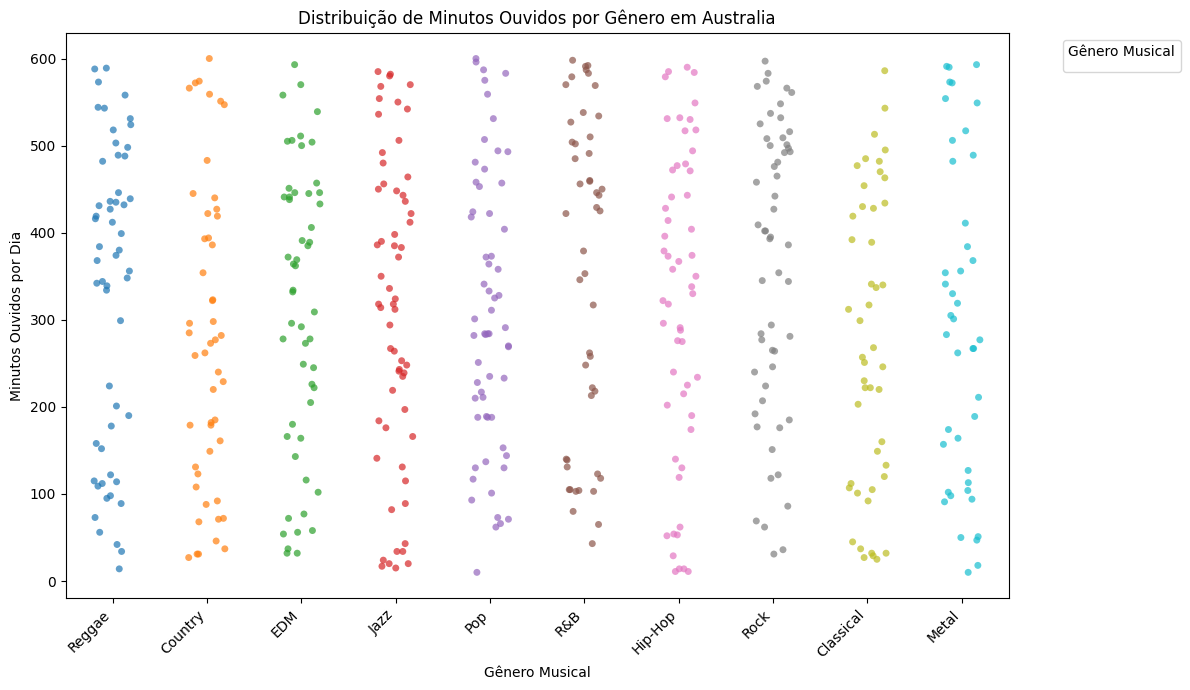

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


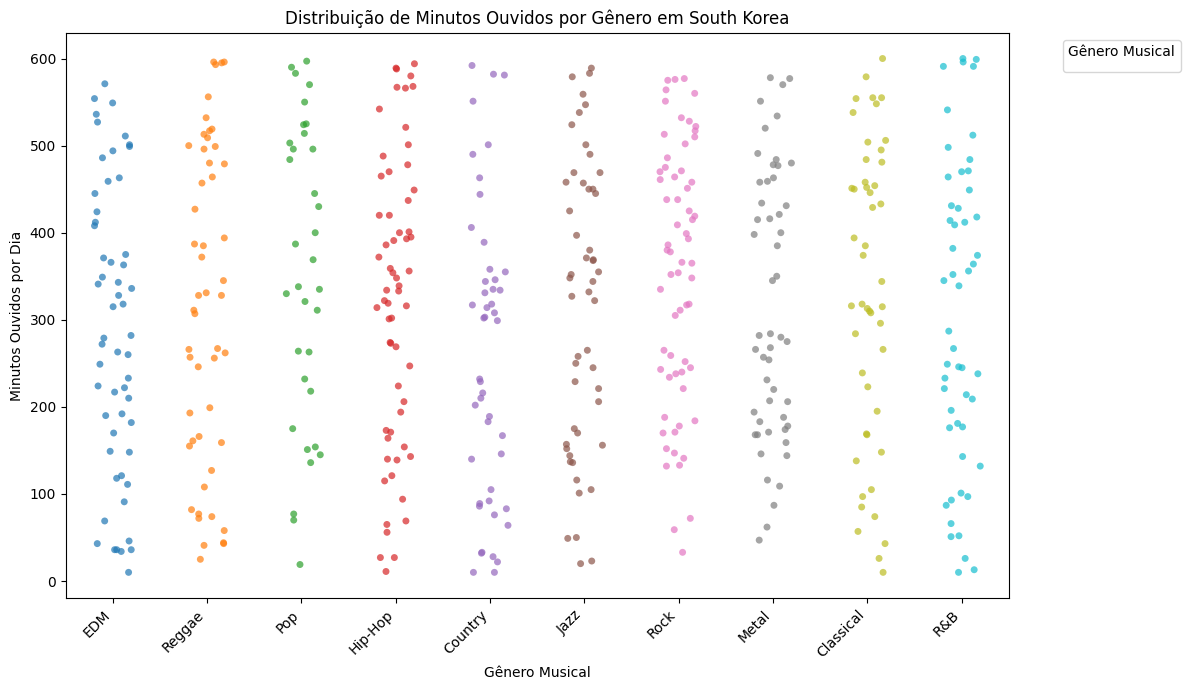

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


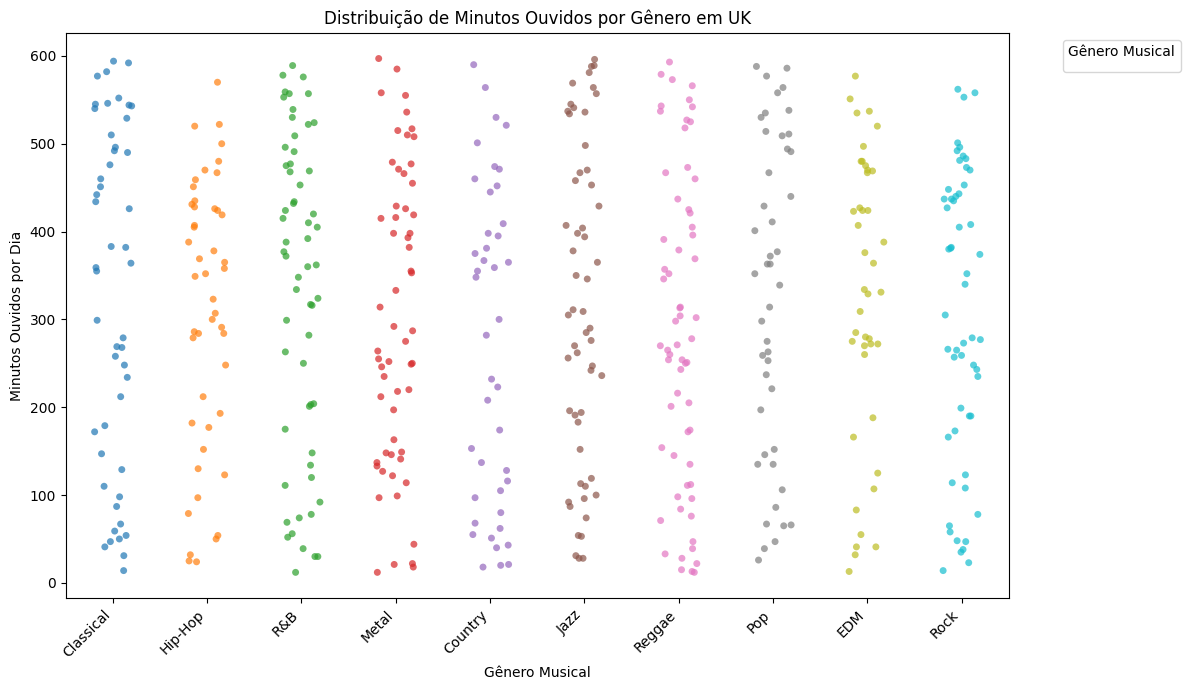

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


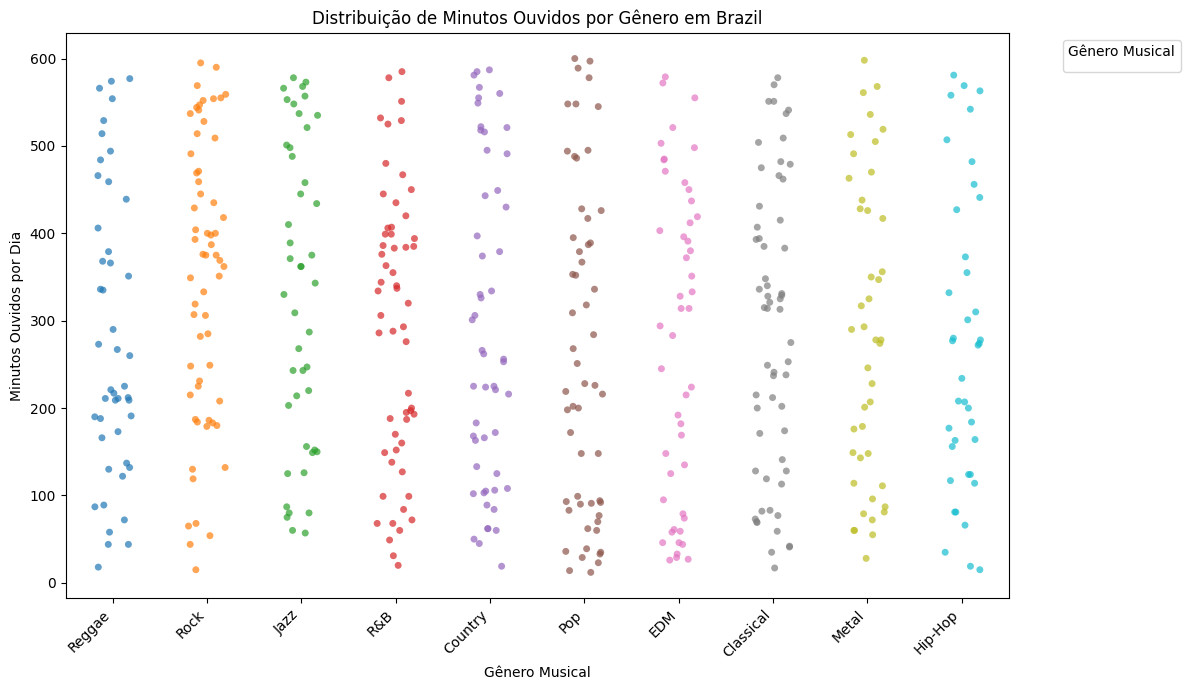

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


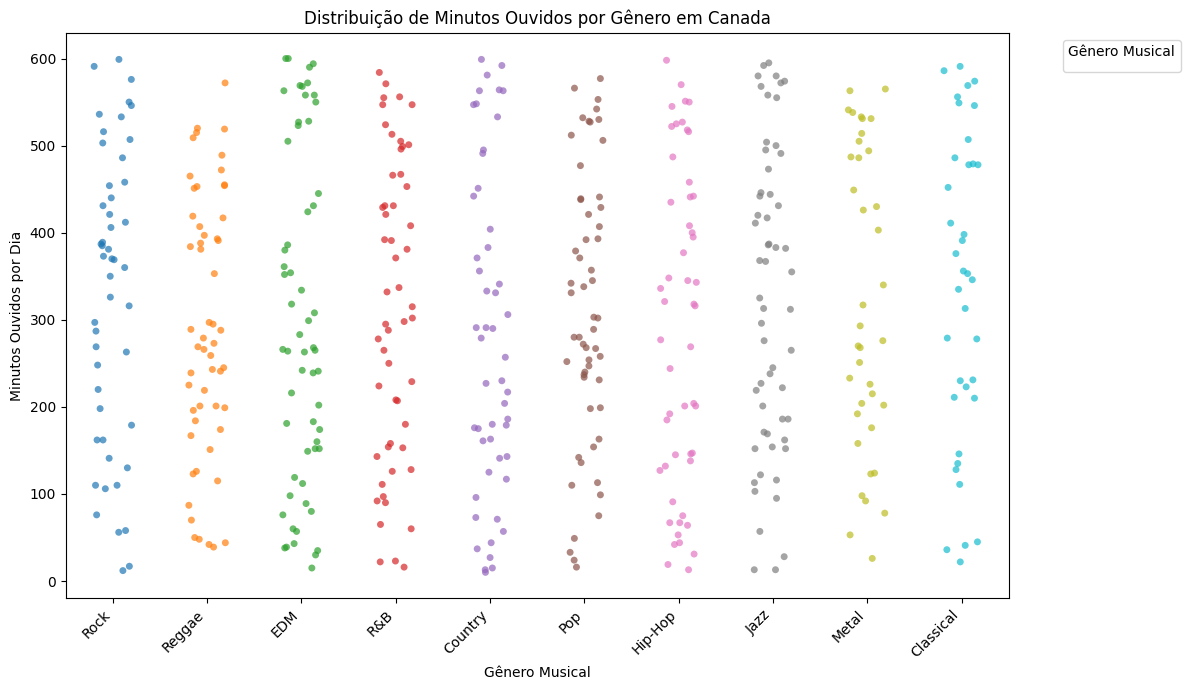

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


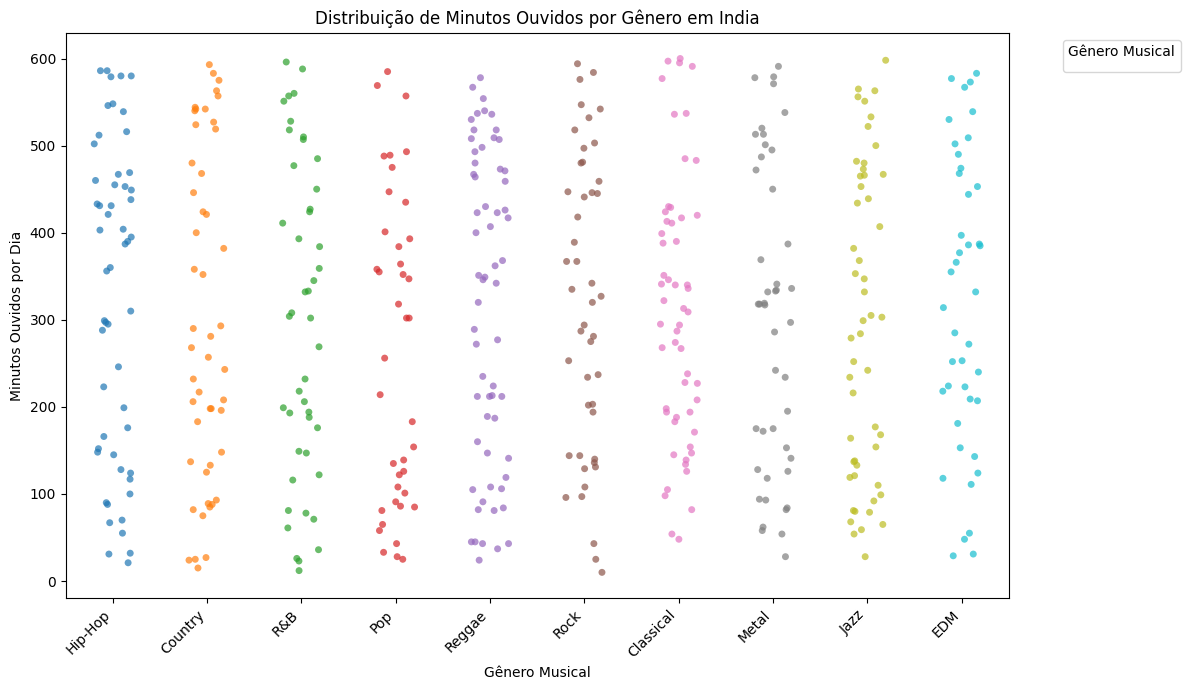

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


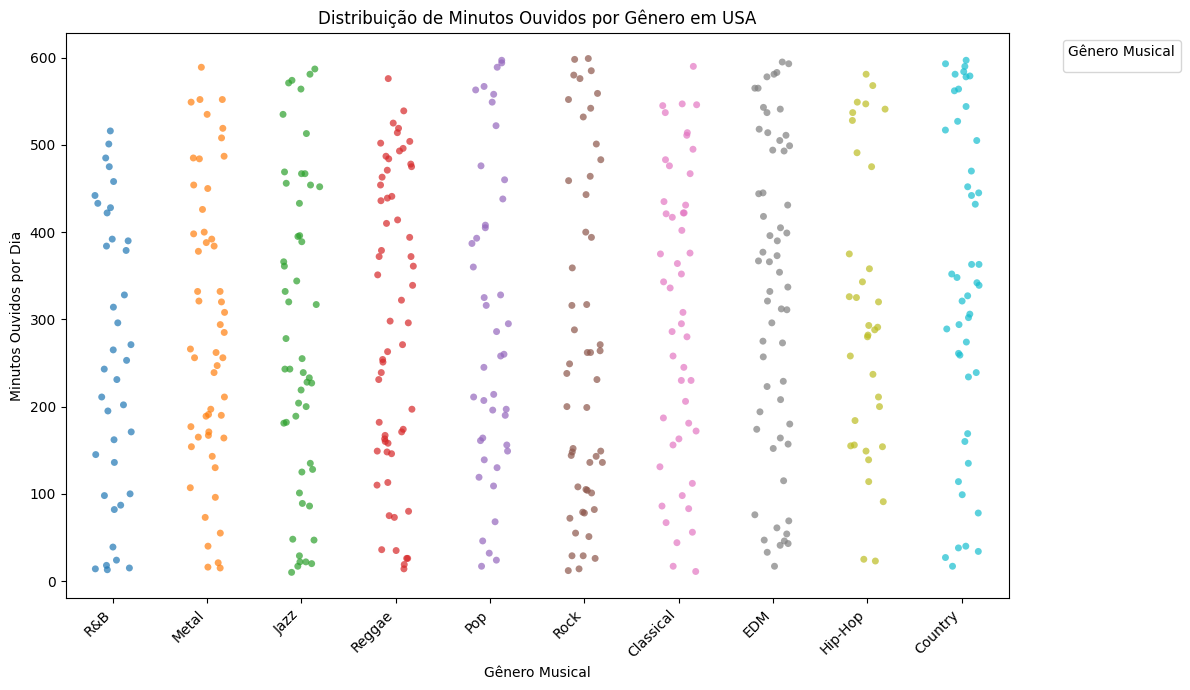

/tmp/ipython-input-2628980142.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')


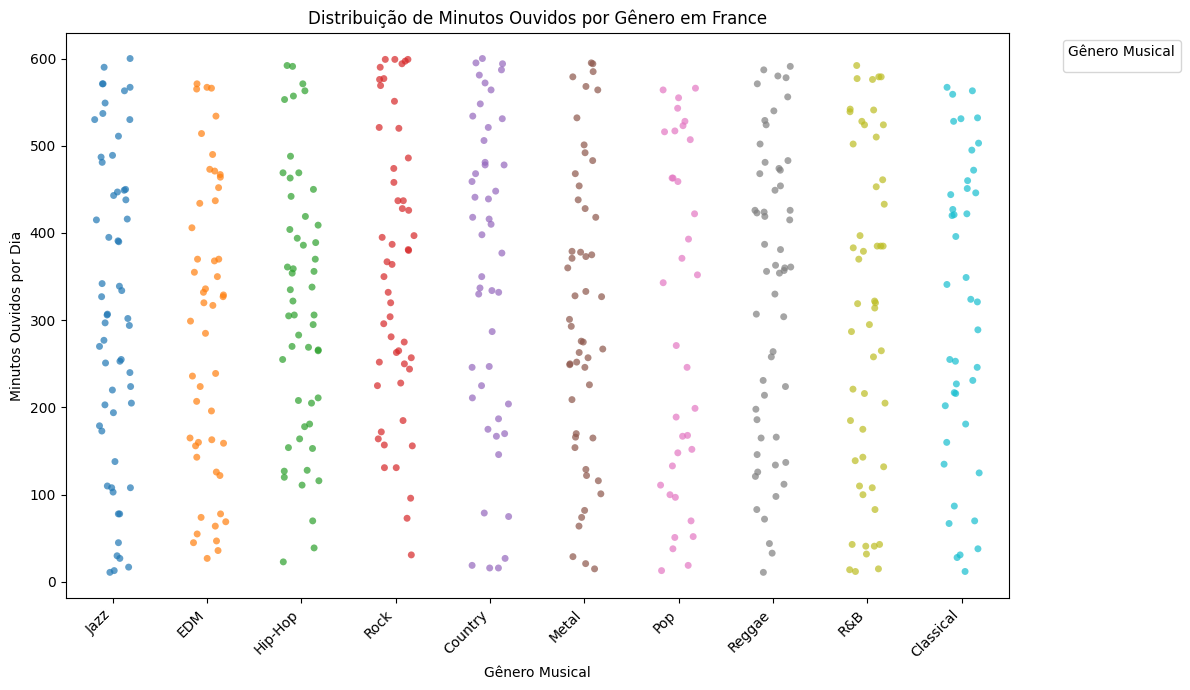

In [ ]:
unique_countries = df_final_features_unified['Country_Name'].unique()

for country in unique_countries:
    df_country = df_final_features_unified[df_final_features_unified['Country_Name'] == country]

    plt.figure(figsize=(12, 7))
    sns.stripplot(
        data=df_country,
        x='Top_Genre_Name',
        y='Minutes Streamed Per Day',
        hue='Top_Genre_Name',
        palette='tab10',
        jitter=0.2,
        alpha=0.7,
        legend=False # Hide individual genre legend in stripplot
    )

    plt.title(f'Distribuição de Minutos Ouvidos por Gênero em {country}')
    plt.xlabel('Gênero Musical')
    plt.ylabel('Minutos Ouvidos por Dia')
    plt.xticks(rotation=45, ha='right')

    # Create a separate legend outside the plot area
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous code generated a 'UserWarning: No artists with labels found to put in legend' because `legend=False` was set in `sns.stripplot`, preventing the creation of legend handles. To fix this, I will remove `legend=False` from the `sns.stripplot` call and explicitly pass the `ax` object to the stripplot, then retrieve the handles and labels from that axis to create a custom legend, ensuring that `handles` are not empty before attempting to create the legend.



ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

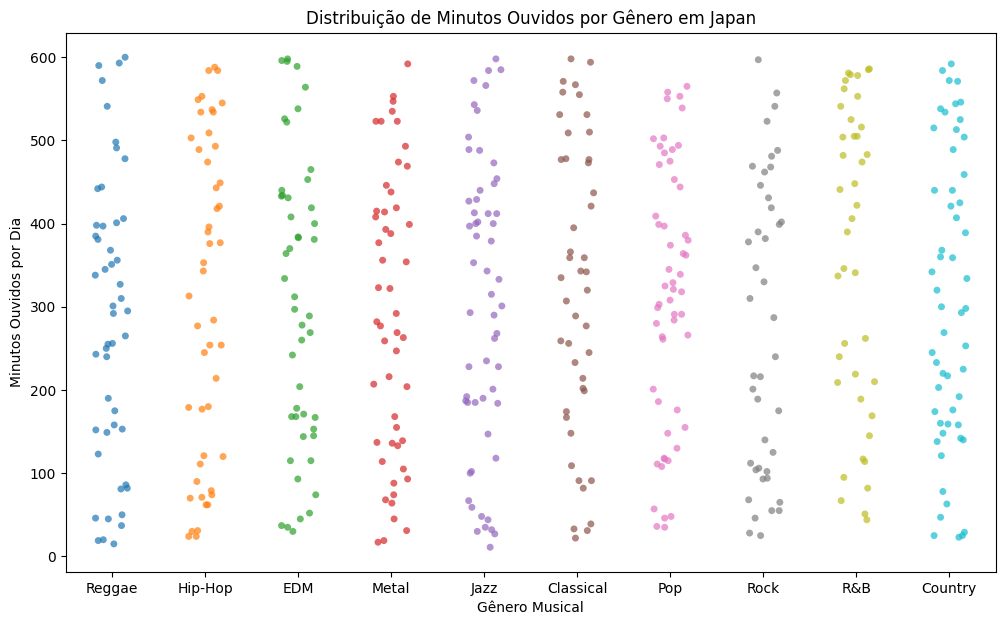

In [ ]:
unique_countries = df_final_features_unified['Country_Name'].unique()

for country in unique_countries:
    df_country = df_final_features_unified[df_final_features_unified['Country_Name'] == country]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.stripplot(
        data=df_country,
        x='Top_Genre_Name',
        y='Minutes Streamed Per Day',
        hue='Top_Genre_Name',
        palette='tab10',
        jitter=0.2,
        alpha=0.7,
        ax=ax # Pass the axis object to seaborn
    )

    ax.set_title(f'Distribuição de Minutos Ouvidos por Gênero em {country}')
    ax.set_xlabel('Gênero Musical')
    ax.set_ylabel('Minutos Ouvidos por Dia')
    ax.tick_params(axis='x', rotation=45, ha='right')

    # Get handles and labels from the current axes and place the legend
    handles, labels = ax.get_legend_handles_labels()
    if handles: # Only create legend if there are handles
        ax.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        print(f"No legend created for {country} as no genres were found or plotted.")

    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous code failed because `ha` (horizontal alignment) is not a valid keyword argument for `ax.tick_params`. The `rotation` argument already handles the label orientation. I will remove the `ha='right'` from `ax.tick_params` to fix this `ValueError`.



No legend created for Japan as no genres were found or plotted.


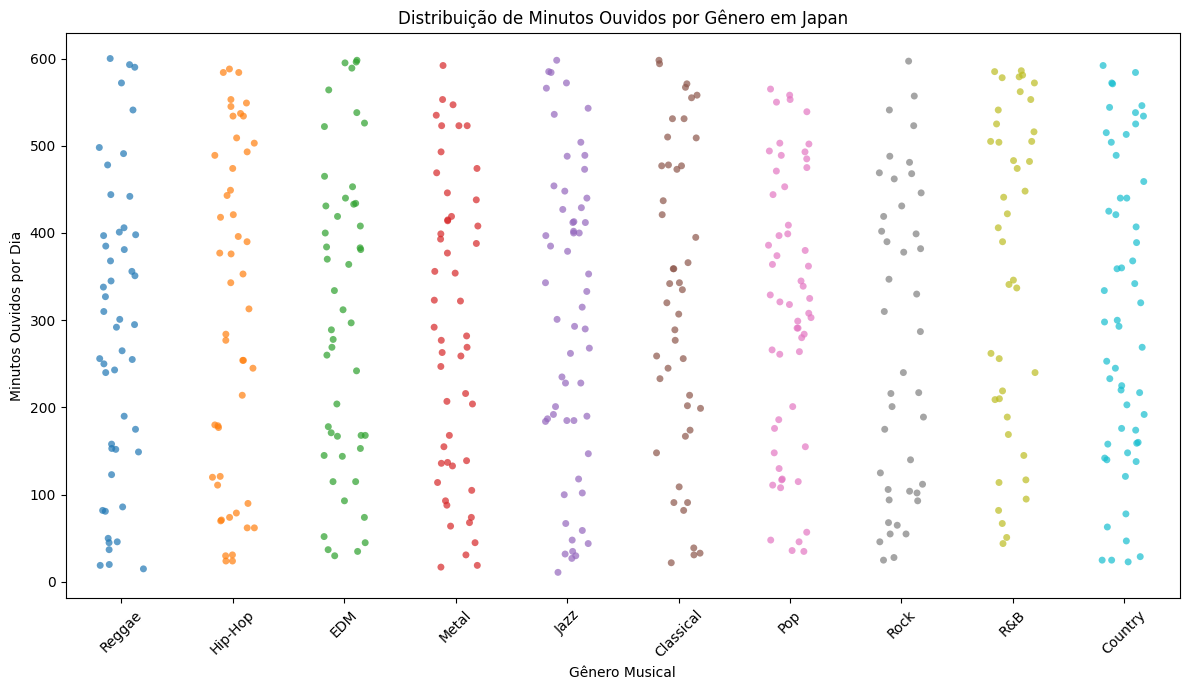

No legend created for Germany as no genres were found or plotted.


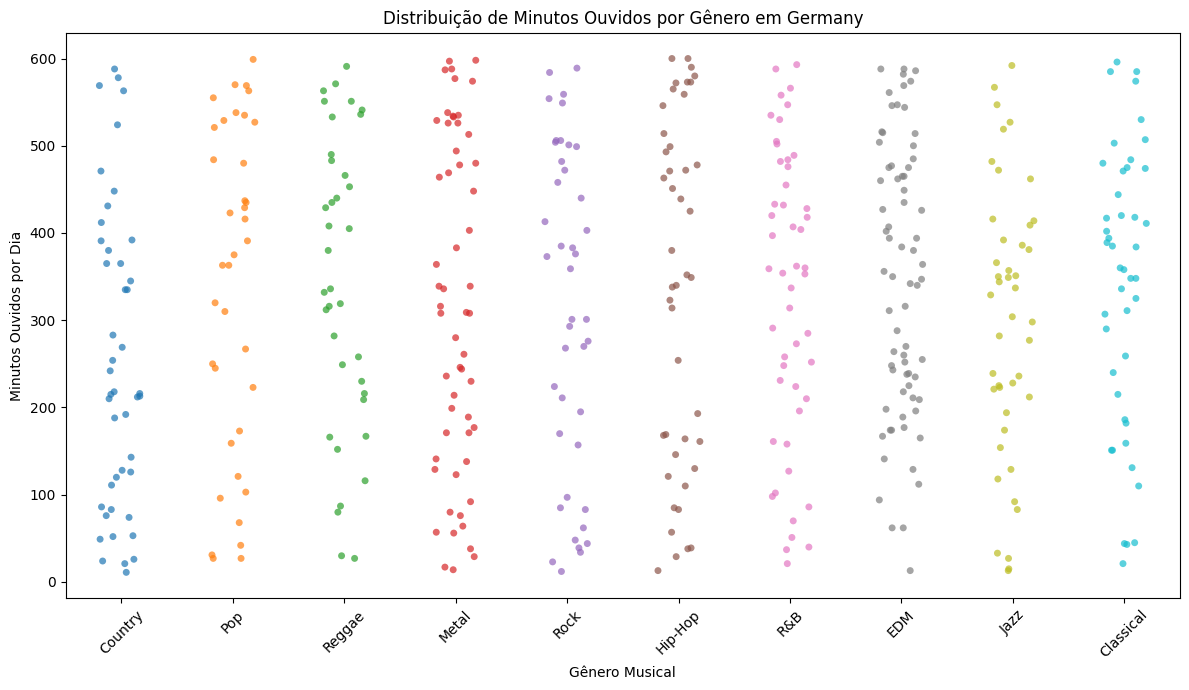

No legend created for Australia as no genres were found or plotted.


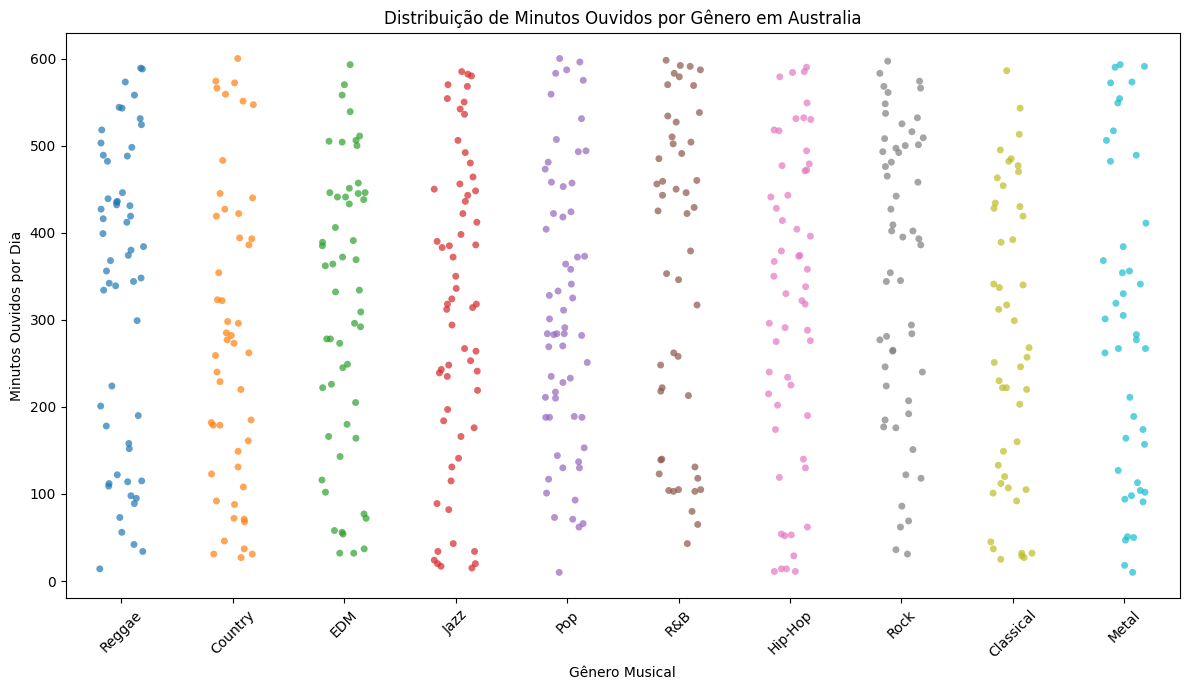

No legend created for South Korea as no genres were found or plotted.


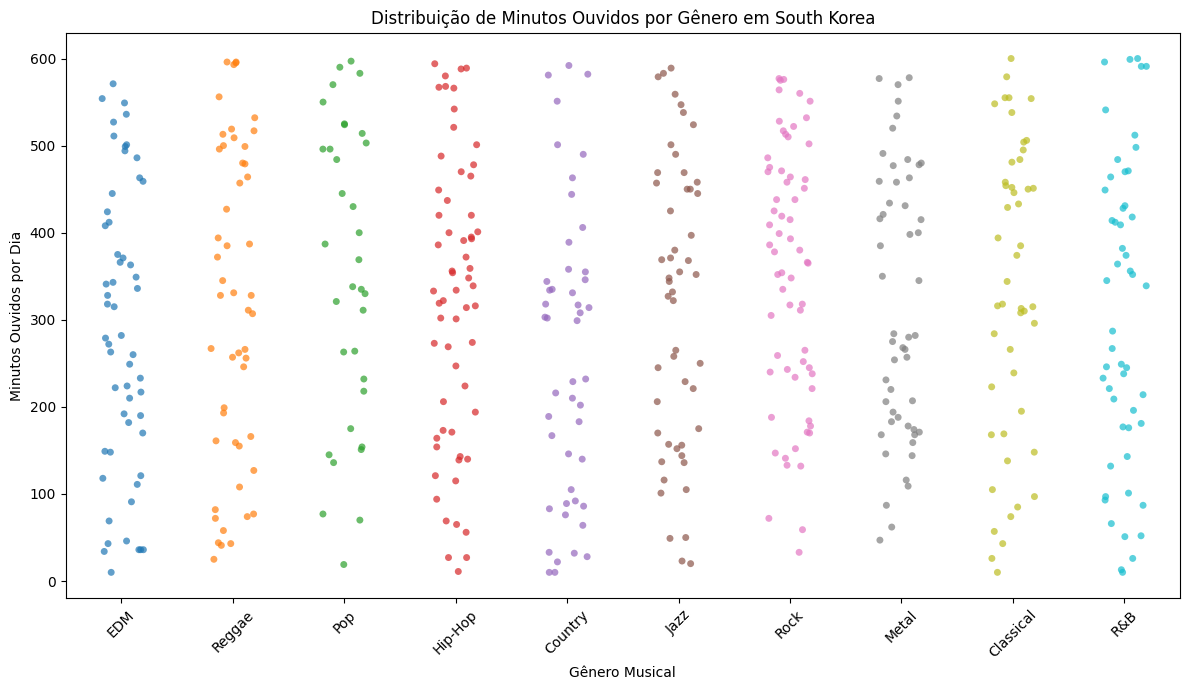

No legend created for UK as no genres were found or plotted.


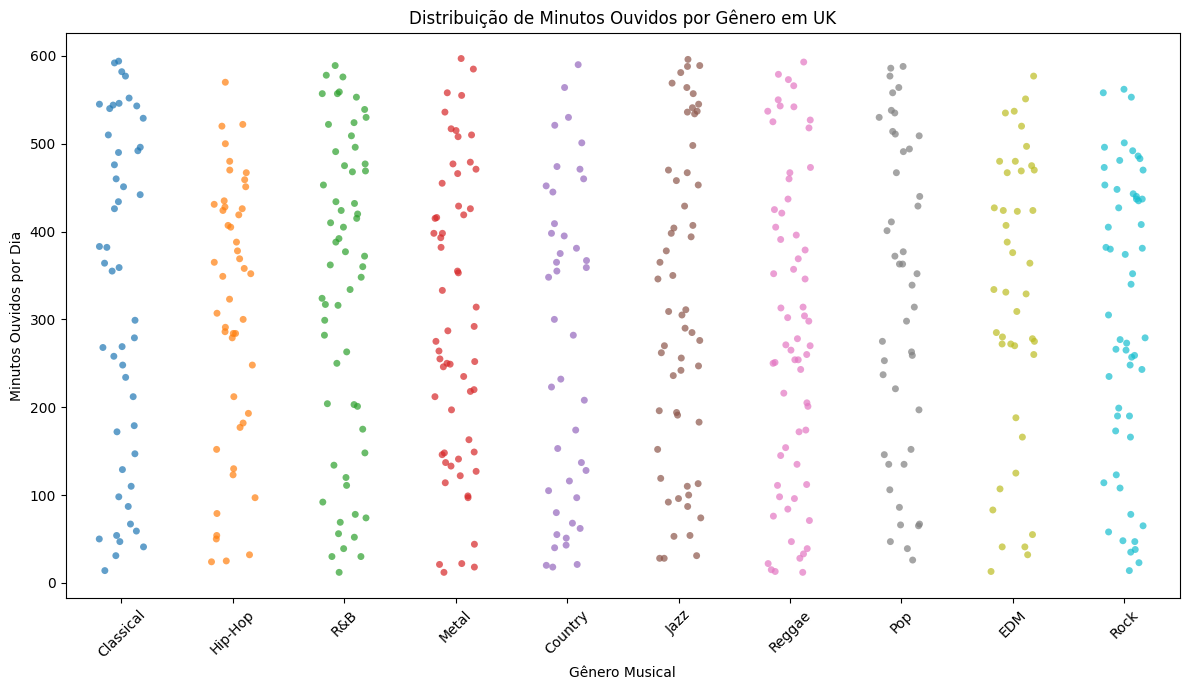

No legend created for Brazil as no genres were found or plotted.


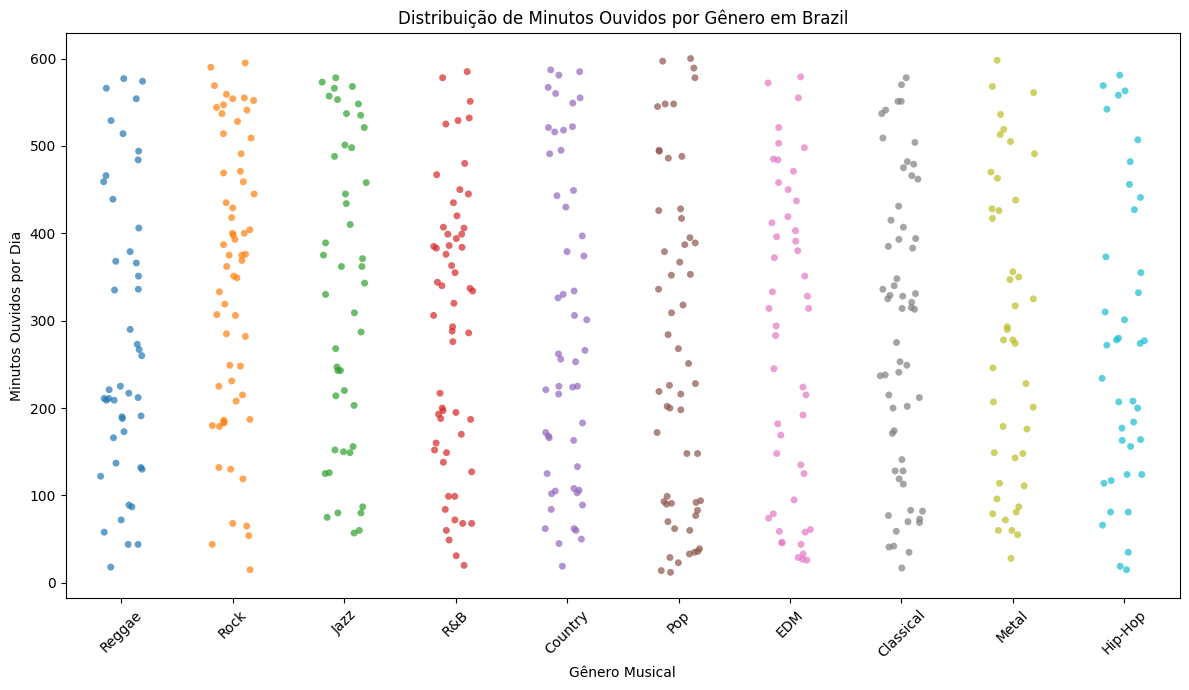

No legend created for Canada as no genres were found or plotted.


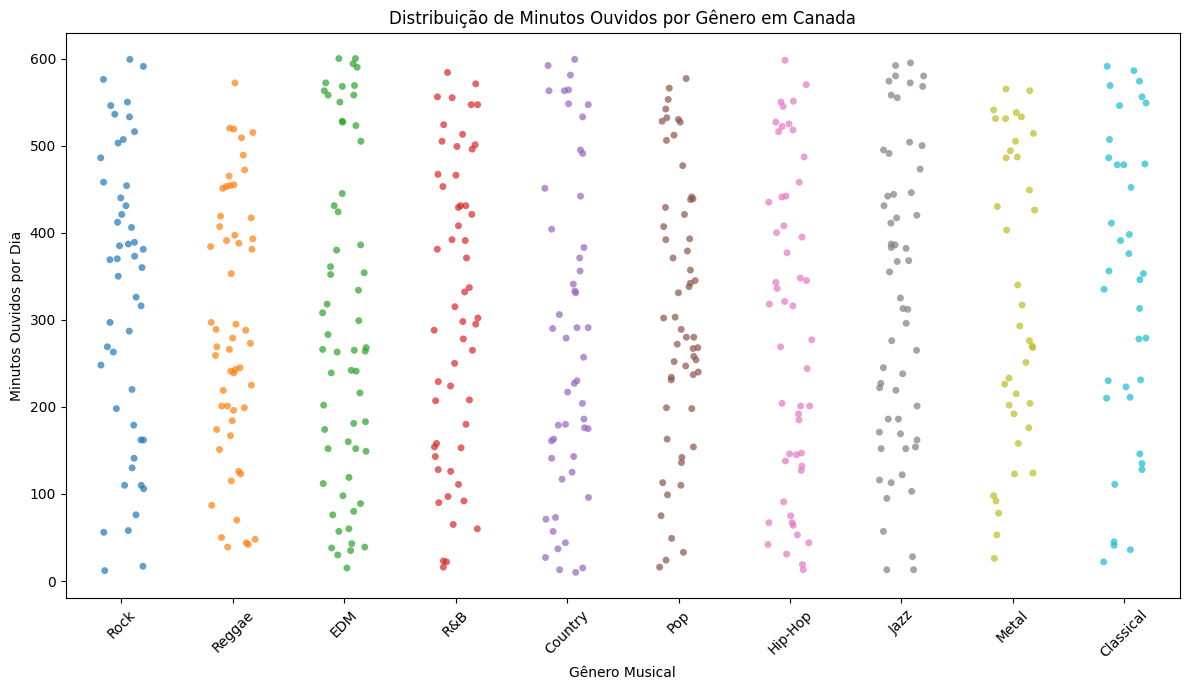

No legend created for India as no genres were found or plotted.


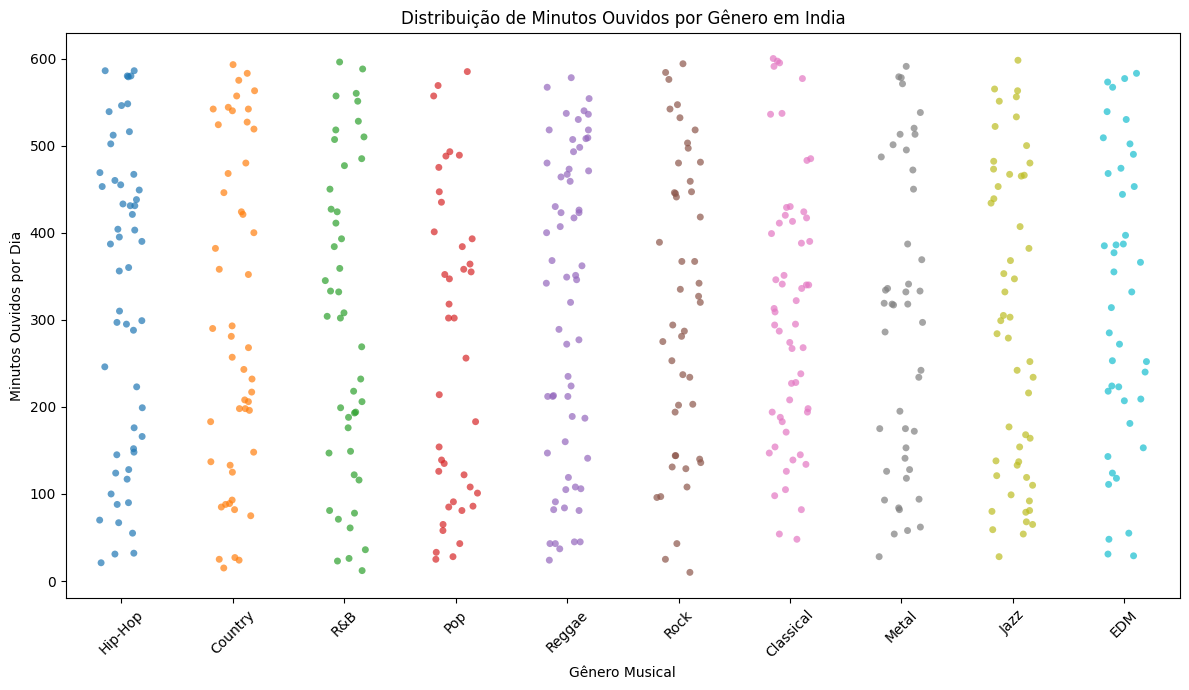

No legend created for USA as no genres were found or plotted.


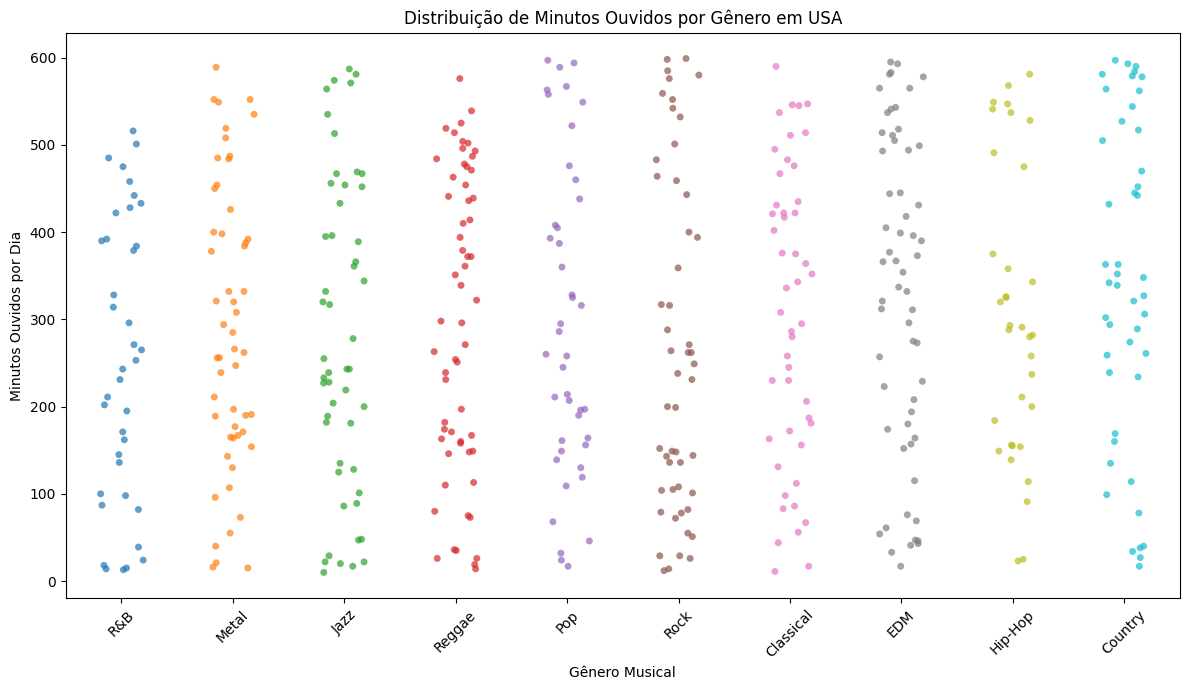

No legend created for France as no genres were found or plotted.


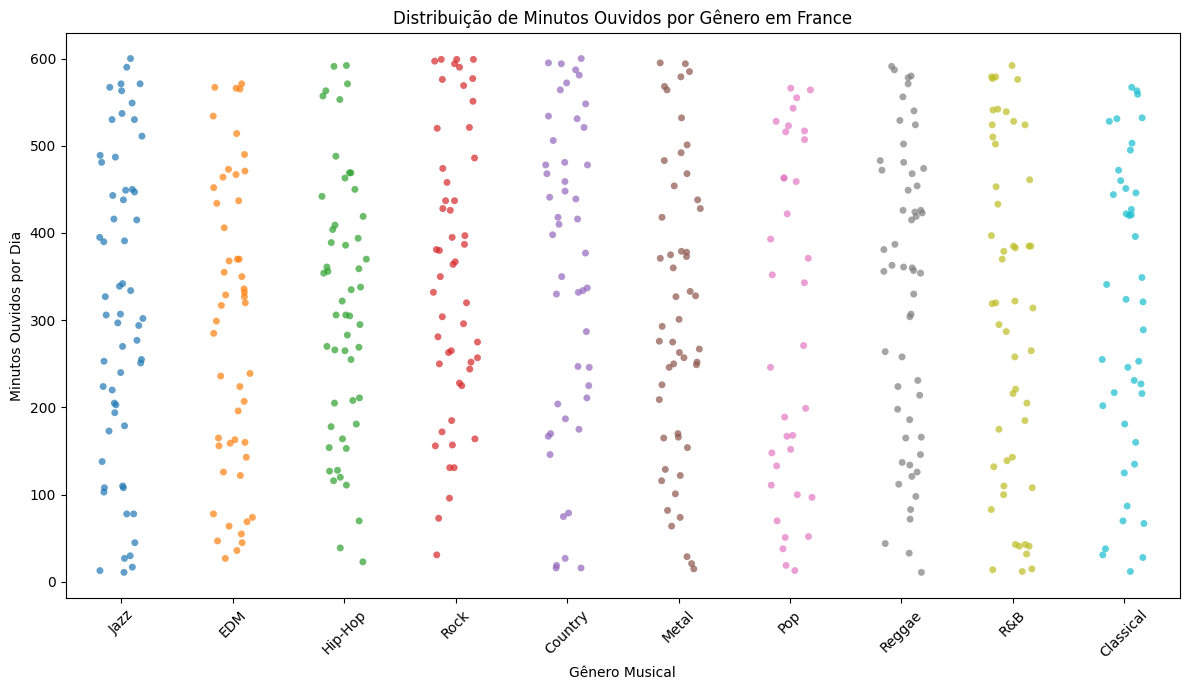

In [ ]:
unique_countries = df_final_features_unified['Country_Name'].unique()

for country in unique_countries:
    df_country = df_final_features_unified[df_final_features_unified['Country_Name'] == country]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.stripplot(
        data=df_country,
        x='Top_Genre_Name',
        y='Minutes Streamed Per Day',
        hue='Top_Genre_Name',
        palette='tab10',
        jitter=0.2,
        alpha=0.7,
        ax=ax # Pass the axis object to seaborn
    )

    ax.set_title(f'Distribuição de Minutos Ouvidos por Gênero em {country}')
    ax.set_xlabel('Gênero Musical')
    ax.set_ylabel('Minutos Ouvidos por Dia')
    ax.tick_params(axis='x', rotation=45)

    # Get handles and labels from the current axes and place the legend
    handles, labels = ax.get_legend_handles_labels()
    if handles: # Only create legend if there are handles
        ax.legend(handles=handles, labels=labels, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        print(f"No legend created for {country} as no genres were found or plotted.")

    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous code failed to generate legends because `ax.get_legend_handles_labels()` returned empty lists, indicating that `stripplot` did not automatically create legend artists in a way that could be easily extracted. To fix this, I will manually create legend handles by mapping unique genres to colors from the chosen palette and then passing these custom handles to `ax.legend()`.



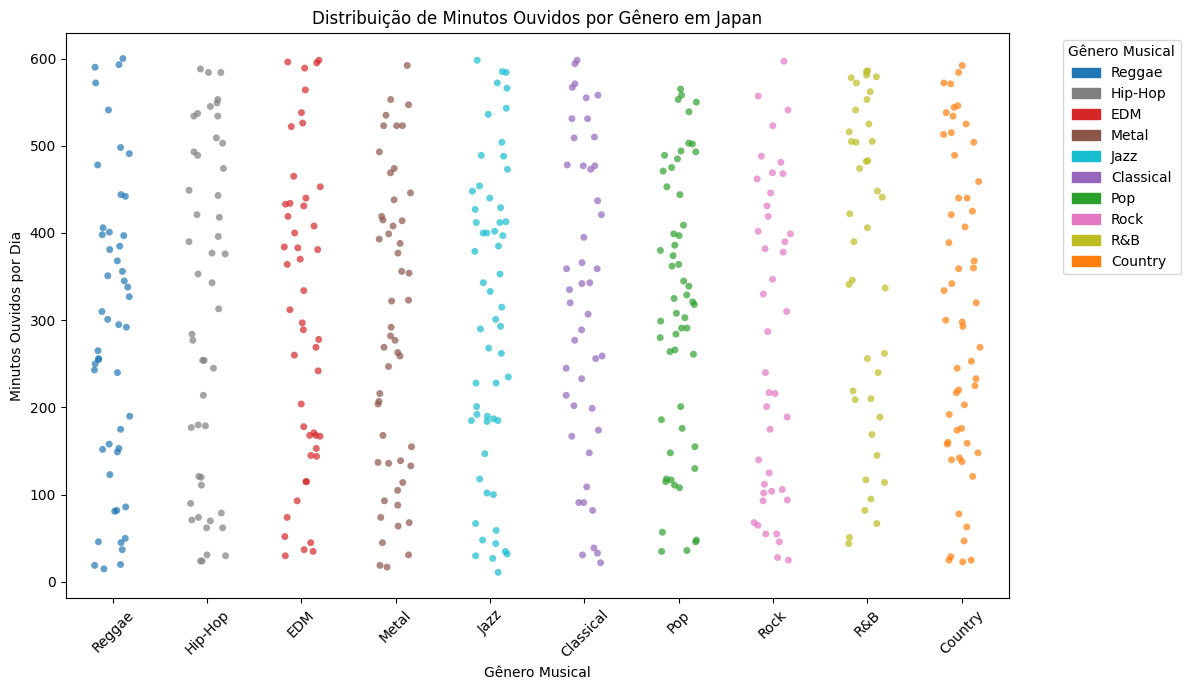

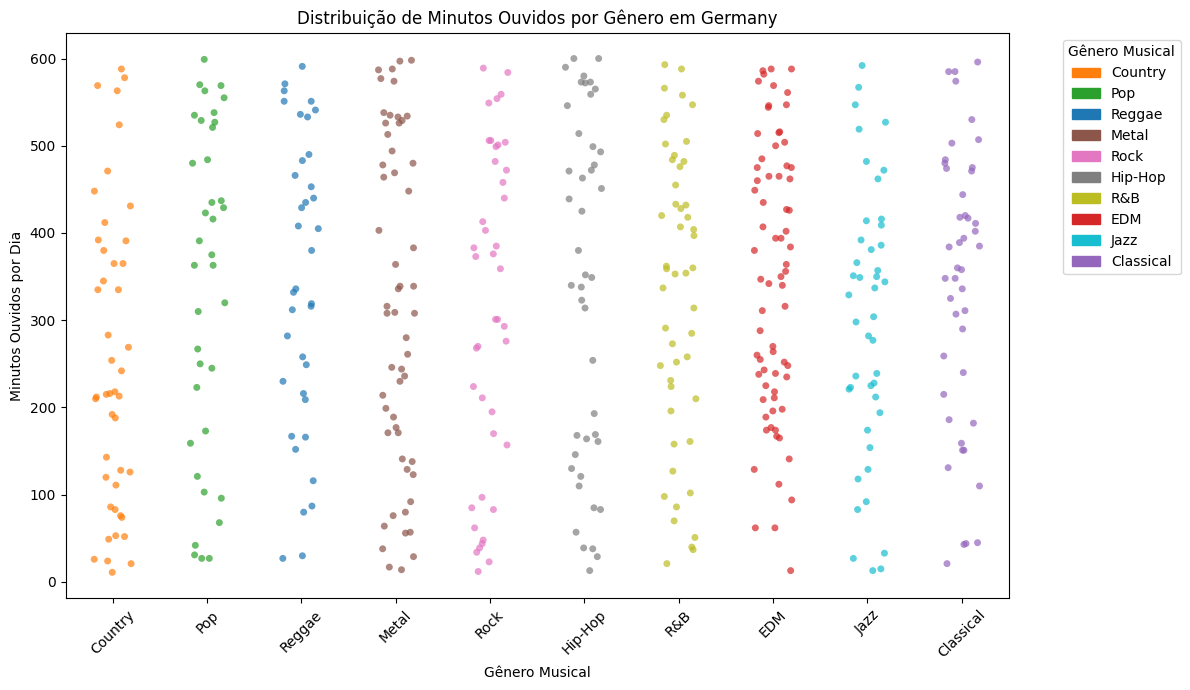

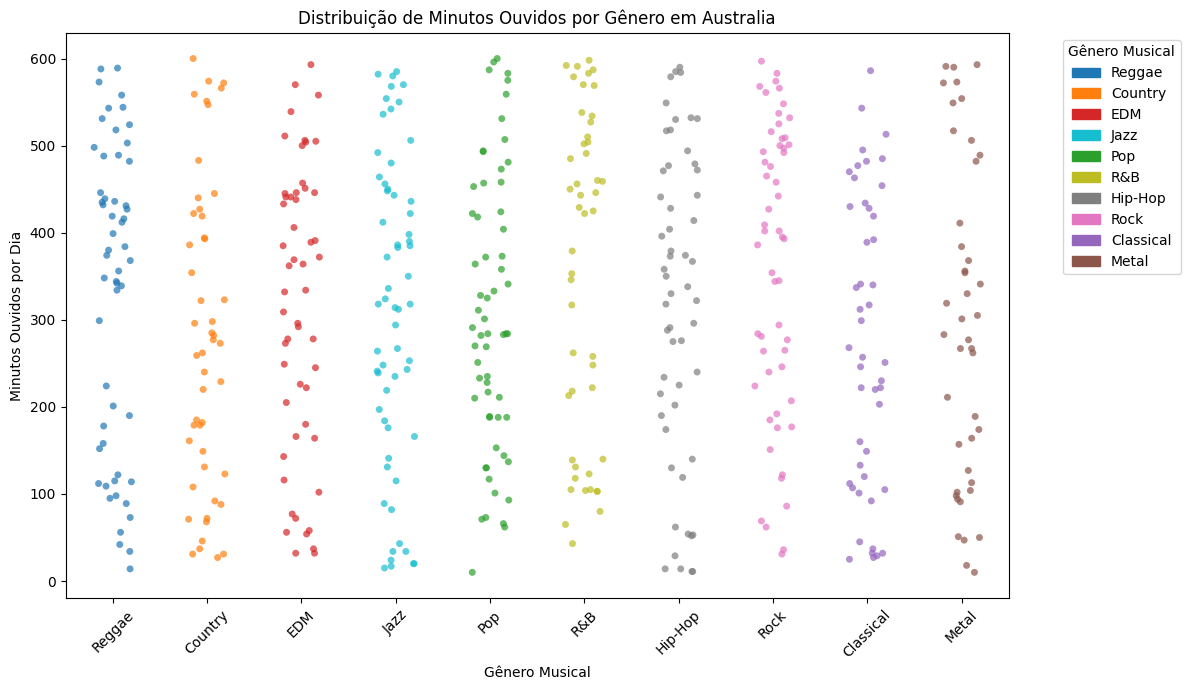

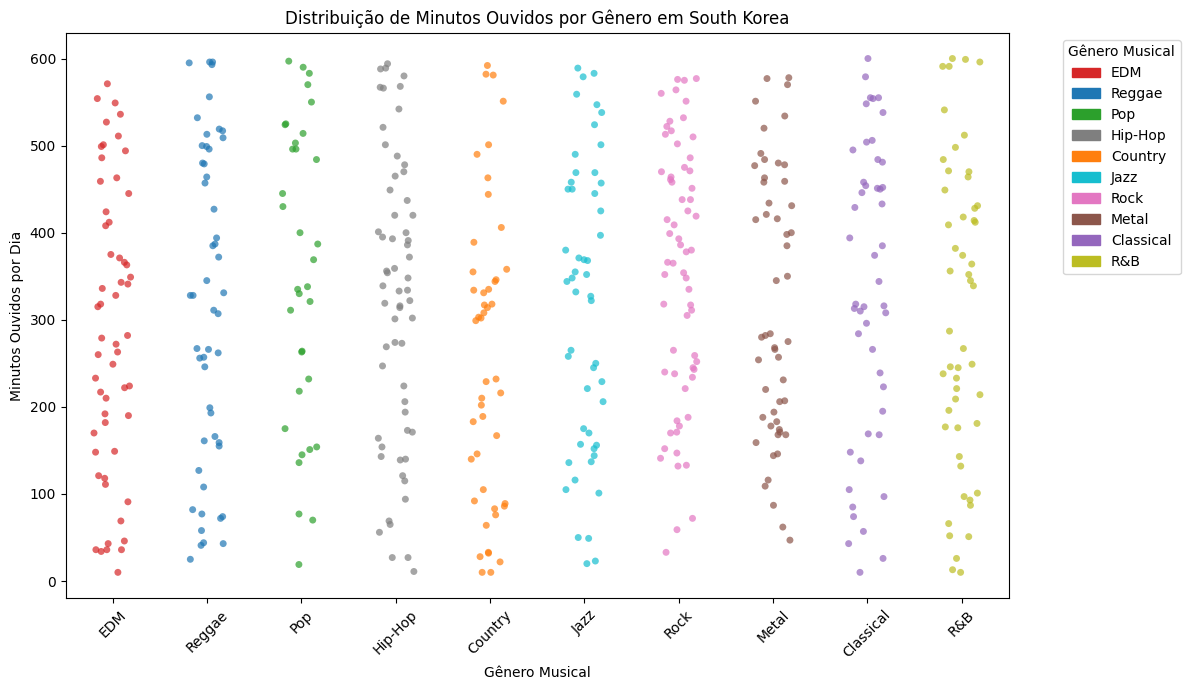

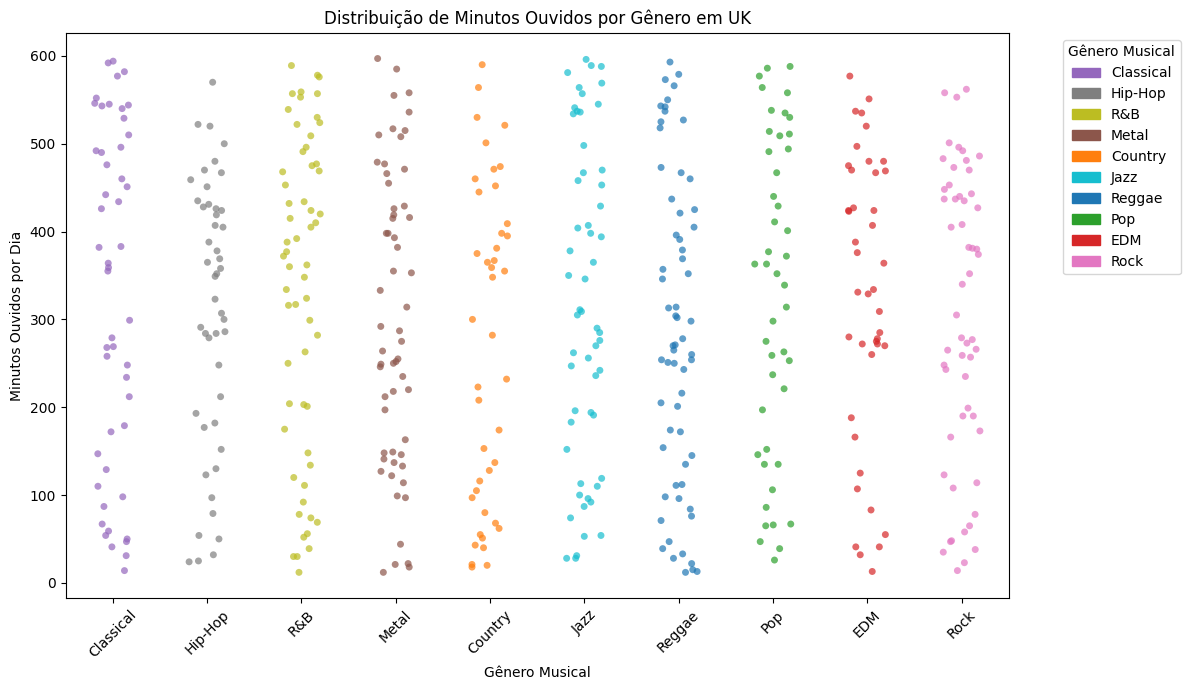

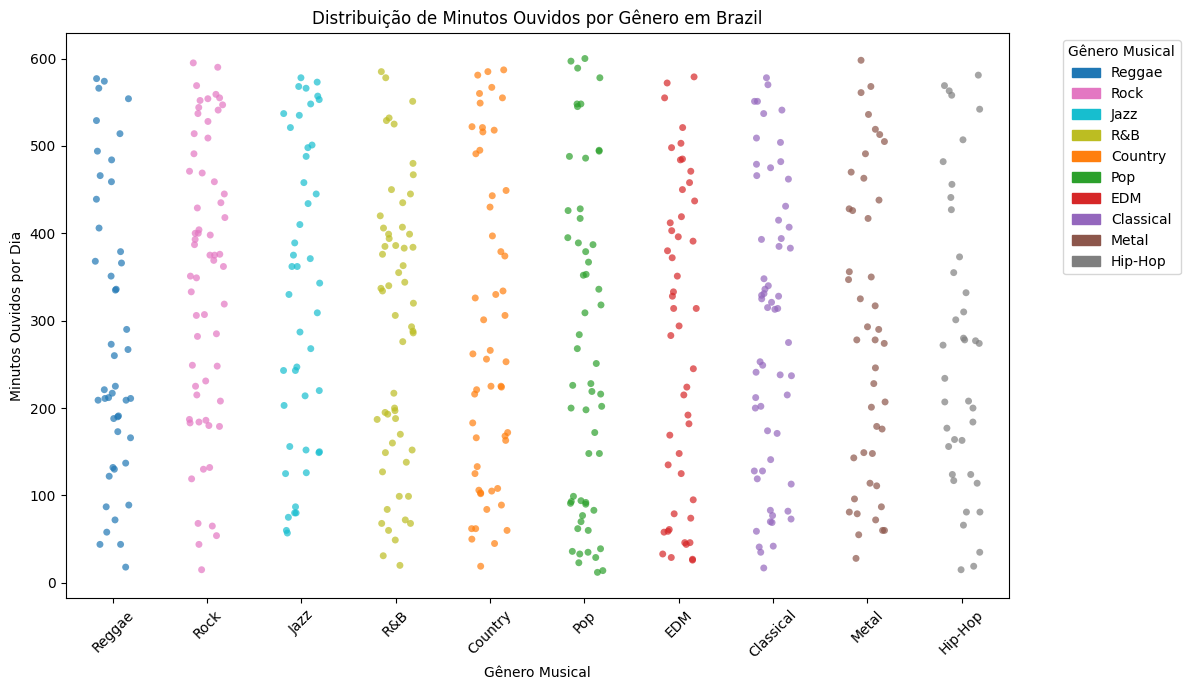

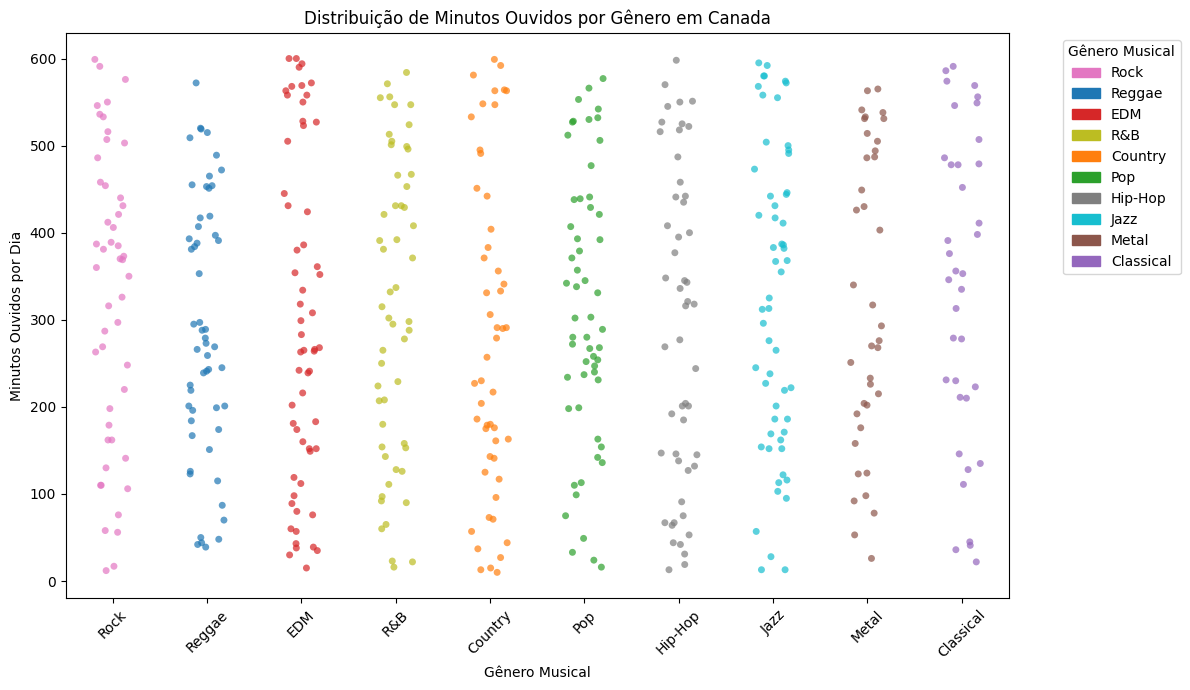

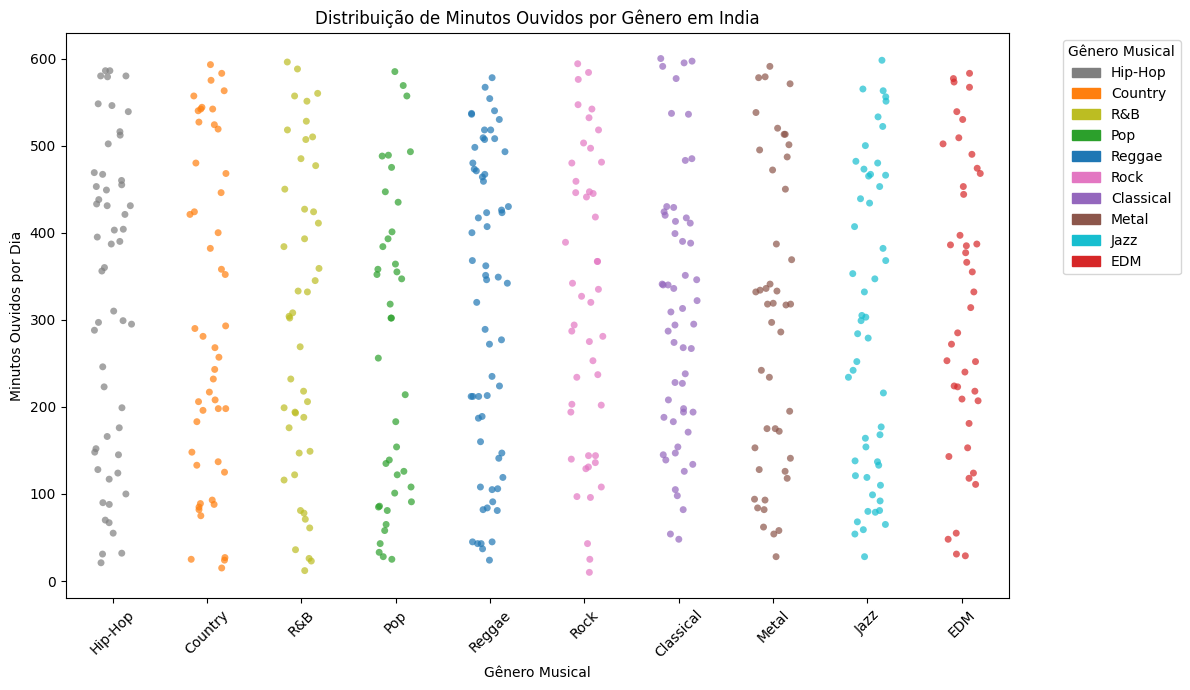

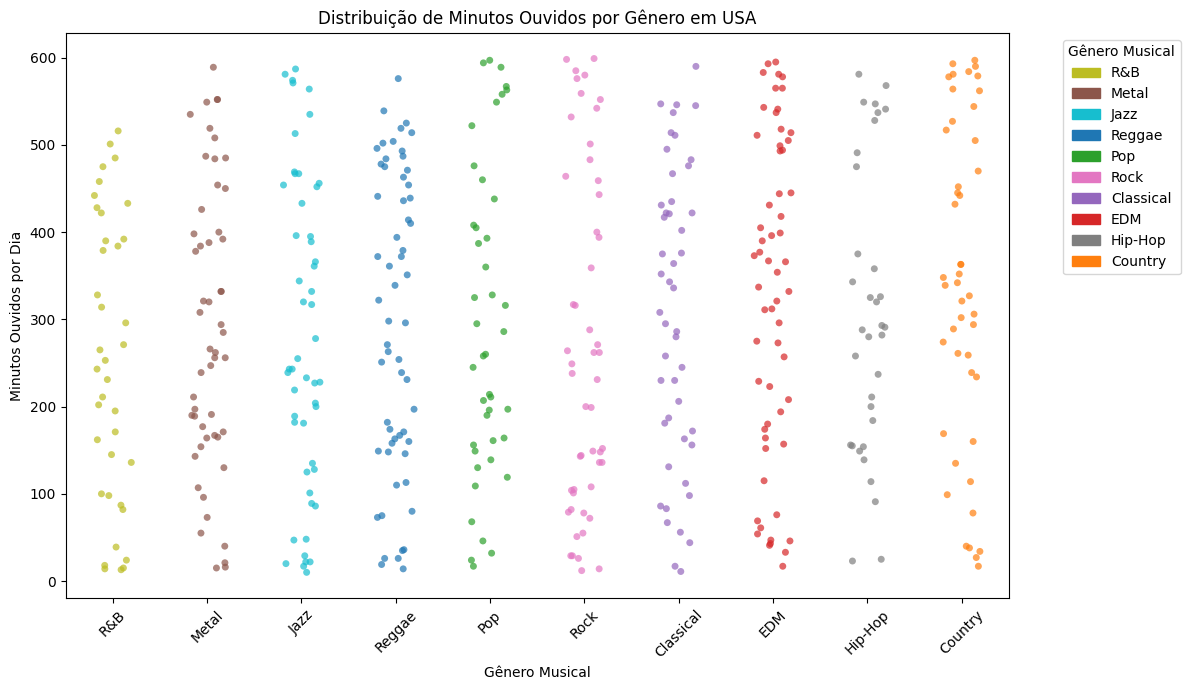

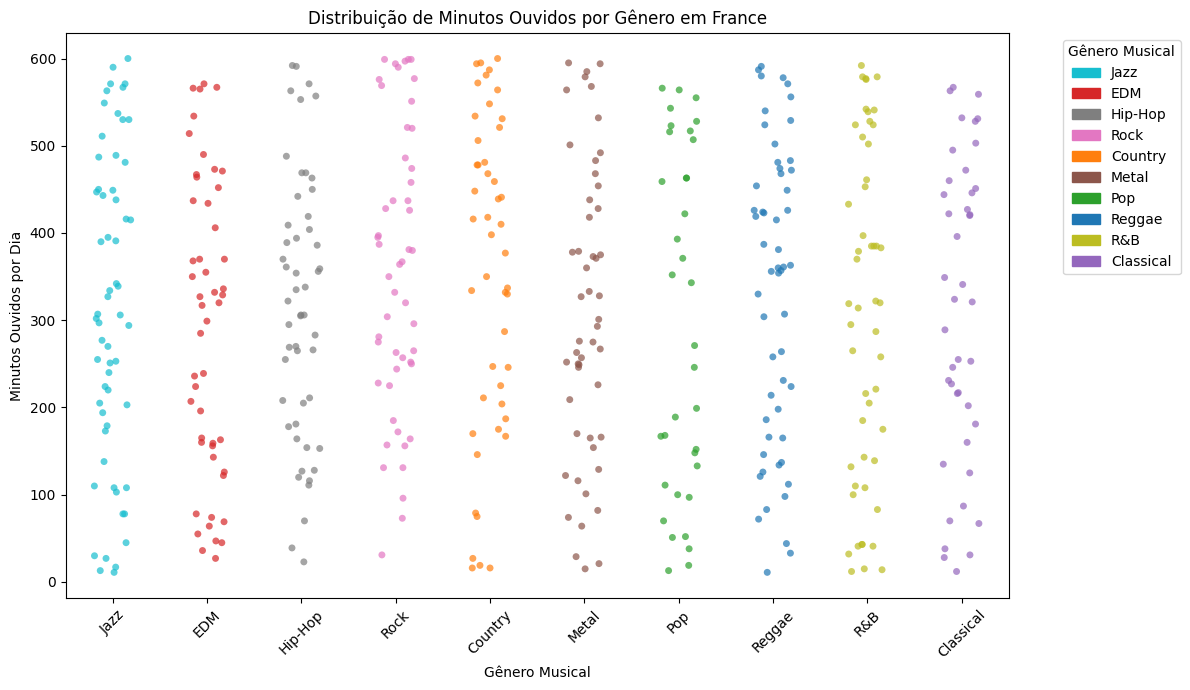

In [ ]:
import matplotlib.patches as mpatches

unique_countries = df_final_features_unified['Country_Name'].unique()

# Get all unique genres from the entire dataframe to ensure consistent color mapping
all_unique_genres = df_final_features_unified['Top_Genre_Name'].unique()
palette = sns.color_palette("tab10", n_colors=len(all_unique_genres))
genre_to_color = {genre: palette[i] for i, genre in enumerate(all_unique_genres)}

for country in unique_countries:
    df_country = df_final_features_unified[df_final_features_unified['Country_Name'] == country]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.stripplot(
        data=df_country,
        x='Top_Genre_Name',
        y='Minutes Streamed Per Day',
        hue='Top_Genre_Name',
        palette=genre_to_color, # Use the consistent genre_to_color mapping
        jitter=0.2,
        alpha=0.7,
        ax=ax
    )

    ax.set_title(f'Distribuição de Minutos Ouvidos por Gênero em {country}')
    ax.set_xlabel('Gênero Musical')
    ax.set_ylabel('Minutos Ouvidos por Dia')
    ax.tick_params(axis='x', rotation=45)

    # Manually create legend handles using patches
    legend_handles = []
    unique_genres_in_country = df_country['Top_Genre_Name'].unique()
    for genre in unique_genres_in_country:
        color = genre_to_color.get(genre) # Get color from the consistent mapping
        if color is not None:
            legend_handles.append(mpatches.Patch(color=color, label=genre))

    if legend_handles:
        ax.legend(handles=legend_handles, title='Gênero Musical', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        # This case should ideally not happen if df_country is not empty and has genres
        print(f"No genres found to create a legend for {country}.")

    plt.tight_layout()
    plt.show()

**Reasoning**:
Now that the visualizations have been successfully generated, the next step is to identify the second most listened genre for each country based on the total 'Minutes Streamed Per Day'. This involves grouping the data, summing the minutes, and then sorting to find the second highest.



In [ ]:
genre_minutes_per_country = df_final_features_unified.groupby(['Country_Name', 'Top_Genre_Name'])['Minutes Streamed Per Day'].sum().reset_index()

second_most_listened_genre = genre_minutes_per_country.groupby('Country_Name').apply(lambda x: x.nlargest(2, 'Minutes Streamed Per Day').iloc[[-1]]).reset_index(drop=True)

print("Segundo gênero musical mais ouvido por país (com base nos minutos totais ouvidos):")
print(second_most_listened_genre)


Segundo gênero musical mais ouvido por país (com base nos minutos totais ouvidos):
  Country_Name Top_Genre_Name  Minutes Streamed Per Day
0    Australia            Pop                     18793
1       Brazil      Classical                     17057
2       Canada            EDM                     17588
3       France         Reggae                     18255
4      Germany          Metal                     17665
5        India        Hip-Hop                     17543
6        Japan            Pop                     17256
7  South Korea        Hip-Hop                     19634
8           UK         Reggae                     18117
9          USA         Reggae                     17535


/tmp/ipython-input-1773038870.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  second_most_listened_genre = genre_minutes_per_country.groupby('Country_Name').apply(lambda x: x.nlargest(2, 'Minutes Streamed Per Day').iloc[[-1]]).reset_index(drop=True)


**Reasoning**:
The previous code generated a DeprecationWarning because `DataFrameGroupBy.apply` operated on grouping columns. To resolve this, I will add `include_groups=False` to the `apply` method, which explicitly tells pandas not to pass the grouping keys to the function.



In [ ]:
genre_minutes_per_country = df_final_features_unified.groupby(['Country_Name', 'Top_Genre_Name'])['Minutes Streamed Per Day'].sum().reset_index()

second_most_listened_genre = genre_minutes_per_country.groupby('Country_Name').apply(lambda x: x.nlargest(2, 'Minutes Streamed Per Day').iloc[[-1]], include_groups=False).reset_index(drop=True)

print("Segundo gênero musical mais ouvido por país (com base nos minutos totais ouvidos):")
print(second_most_listened_genre)


Segundo gênero musical mais ouvido por país (com base nos minutos totais ouvidos):
  Top_Genre_Name  Minutes Streamed Per Day
0            Pop                     18793
1      Classical                     17057
2            EDM                     17588
3         Reggae                     18255
4          Metal                     17665
5        Hip-Hop                     17543
6            Pop                     17256
7        Hip-Hop                     19634
8         Reggae                     18117
9         Reggae                     17535


## Exibir Recomendações de Gêneros

### Subtask:
Present a clear list of each country and its respective second most listened musical genre, which can be used as a basis for advertising recommendations.


**Reasoning**:
The previous recalculation of `second_most_listened_genre` using `reset_index(drop=True)` resulted in the loss of the 'Country_Name' column. To correctly include 'Country_Name' in the output, I need to recalculate it while ensuring 'Country_Name' is retained as a column after the `groupby().apply()` operation by using `reset_index(drop=False)`.



In [ ]:
genre_minutes_per_country = df_final_features_unified.groupby(['Country_Name', 'Top_Genre_Name'])['Minutes Streamed Per Day'].sum().reset_index()

second_most_listened_genre = genre_minutes_per_country.groupby('Country_Name').apply(
    lambda x: x.nlargest(2, 'Minutes Streamed Per Day').iloc[[-1]],
    include_groups=False # This ensures 'x' does not contain 'Country_Name' as a column in the lambda's input
).reset_index(drop=False) # Retain 'Country_Name' from the grouping as a column

print("Segundo gênero musical mais ouvido por país (com base nos minutos totais ouvidos):")
print(second_most_listened_genre)


Segundo gênero musical mais ouvido por país (com base nos minutos totais ouvidos):
  Country_Name  level_1 Top_Genre_Name  Minutes Streamed Per Day
0    Australia        6            Pop                     18793
1       Brazil       10      Classical                     17057
2       Canada       22            EDM                     17588
3       France       38         Reggae                     18255
4      Germany       45          Metal                     17665
5        India       53        Hip-Hop                     17543
6        Japan       66            Pop                     17256
7  South Korea       73        Hip-Hop                     19634
8           UK       88         Reggae                     18117
9          USA       98         Reggae                     17535


### Recomendações de Gêneros para Publicidade Direcionada

Com base na análise, identificamos o segundo gênero musical mais ouvido em cada país, o que oferece insights valiosos para campanhas de publicidade direcionada:

*   **Austrália**: Pop
*   **Brasil**: Classical
*   **Canadá**: EDM
*   **França**: Reggae
*   **Alemanha**: Metal
*   **Índia**: Hip-Hop
*   **Japão**: Pop
*   **Coréia do Sul**: Hip-Hop
*   **Reino Unido**: Reggae
*   **EUA**: Reggae

Essas informações podem ser utilizadas para:

1.  **Personalizar Anúncios**: Empresas de streaming de música e anunciantes podem criar campanhas específicas que promovem o segundo gênero mais popular para ouvintes em cada país. Isso pode incluir playlists curadas, recomendações de artistas e eventos relacionados.
2.  **Otimizar Conteúdo**: Plataformas podem focar na aquisição e promoção de conteúdo (músicas, podcasts, documentários) dentro desses gêneros secundários para aumentar o engajamento e a retenção de usuários que buscam diversidade além dos gêneros mais dominantes.
3.  **Identificar Oportunidades de Mercado**: Para gravadoras e artistas, a popularidade de um gênero secundário pode indicar um nicho de mercado com grande potencial de crescimento e engajamento, orientando futuras produções e estratégias de lançamento.
4.  **Campanhas de Aquisição**: Anúncios direcionados a novos usuários em cada país podem destacar a riqueza de opções nesses gêneros, atraindo ouvintes que talvez não se sintam totalmente representados pelos gêneros de maior audiência.

## Finalizar Tarefa

### Subtask:
Resumir as análises e as recomendações de gêneros musicais por país.


## Summary:

### Q&A
The second most listened musical genre in each country, based on total minutes listened, is as follows:
*   **Australia**: Pop
*   **Brazil**: Classical
*   **Canada**: EDM
*   **France**: Reggae
*   **Germany**: Metal
*   **India**: Hip-Hop
*   **Japan**: Pop
*   **South Korea**: Hip-Hop
*   **United Kingdom**: Reggae
*   **USA**: Reggae

### Data Analysis Key Findings
*   A new column, `Top_Genre_Name`, was successfully added to the `df_final_features_unified` DataFrame, mapping `Top Genre_ID` to their corresponding genre names, such as 'Reggae', 'Country', and 'Pop'.
*   Stripplots were generated for each country, visually representing the distribution of 'Minutos Ouvidos por Dia' across different musical genres, offering a granular view of listening habits.
*   The analysis identified the second most listened genre in each country based on the sum of 'Minutos Ouvidos por Dia'. For instance, 'Pop' is the second most listened genre in Australia, 'Classical' in Brazil, and 'Reggae' in France, the United Kingdom, and the USA.

### Insights or Next Steps
*   Leverage the identified second most popular genres in each country for targeted advertising campaigns, content optimization, and identification of niche market opportunities.
*   Personalize ad content and curated playlists to cater to these secondary popular genres, potentially increasing user engagement and attracting new users who might be underserved by mainstream genre promotions.
